# Chapter 3: Moduli Spaces and Transversality

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 3, Sections 3.1-3.5, printed pp. 39-74; PDF pp. 54-89. The PDF span was used only to orient definitions, theorem order, and notation.

## Chapter Goal

This notebook turns the chapter's analytic transversality package into inspectable finite models. By the end, the central question should be operational:

> when does the zero set of the nonlinear Cauchy-Riemann operator look locally like the kernel of its linearization, and how do generic choices of `J` and point constraints change that local model?

## Computational Translation Guide

| Chapter object | Computational proxy used here | What to inspect |
| --- | --- | --- |
| nonlinear Cauchy-Riemann section `F(u)=bar partial_J u` | residual map on a Banach bundle, modeled by a nonlinear finite map | zero set, derivative, and quadratic remainder |
| linearized operator `D_u` | rectangular matrix with rank, kernel, and cokernel | cokernel dimension detects failure of regularity |
| regular curve / regular `J` | surjective linearization, or surjective projection from the universal moduli space | rank reaches the target dimension |
| elliptic regularity | invariance of kernel and cokernel under Sobolev completions | the finite model records rank data independent of presentation |
| Chern-number splitting over `CP1` | list of line-bundle degrees | each summand degree at least `-1` kills the cokernel |
| pointwise constraints | evaluation map plus codimension bookkeeping | expected dimension after constraints |
| quantitative implicit function theorem | right inverse plus a quadratic estimate | a small residual has a unique correction in the right-inverse direction |


## Source Coverage

The required planner pass is recorded in the notebook before the computations. The source span is organized into five teaching targets:

1. **Section 3.1:** simple-curve moduli spaces; the explicit linearization of the Cauchy-Riemann section; regular `J`; regular homotopies; elliptic regularity; independence of kernel and cokernel from Sobolev choices.
2. **Section 3.2:** universal moduli space; variation in the almost complex structure; why injective points of simple curves make the tangent-space variation large enough; Sard-Smale as the route from universal regularity to generic regular fibers.
3. **Section 3.3:** automatic regularity criteria for spheres via Chern-number splitting; the four-dimensional embedded/immersed sphere criterion; examples where normal degree explains regular and nonregular behavior.
4. **Section 3.4:** pointwise constraints; evaluation maps at fixed domain points; expected codimension and the need to vary `J` with support control.
5. **Section 3.5:** quantitative implicit function theorem; uniformly bounded right inverse; quadratic estimate; existence and uniqueness of a nearby genuine curve.

The notebook does not reproduce source prose or figures. The JSON check below records the coverage claim in machine-readable form for later audit.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "J-Holomorphic-Curves-and-Symplectic-Topology"]:
            if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("JHCST book root not found")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "chapter-03"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
HTML_DIR = ARTIFACT_ROOT / "html"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()


source_coverage = {
    "source_span": {
        "printed_pages": "39-74",
        "pdf_pages": "54-89",
        "sections": ["3.1", "3.2", "3.3", "3.4", "3.5"],
    },
    "coverage": [
        {
            "section": "3.1",
            "topics": [
                "simple curve moduli spaces",
                "linearization formula",
                "regular J and regular homotopies",
                "elliptic regularity",
                "kernel and cokernel independence from Sobolev choices",
            ],
            "implemented_by": ["translation guide", "expected dimension ledger", "rank/cokernel ledger"],
        },
        {
            "section": "3.2",
            "topics": ["universal moduli", "J-variation tangent term", "Sard-Smale regular values"],
            "implemented_by": ["rank/cokernel ledger", "proof dependency graph"],
        },
        {
            "section": "3.3",
            "topics": ["Chern-number splitting", "regularity criterion", "embedded and immersed spheres"],
            "implemented_by": ["Chern splitting visual", "symbolic threshold checks"],
        },
        {
            "section": "3.4",
            "topics": ["pointwise constraints", "evaluation maps", "constraint codimension"],
            "implemented_by": ["expected dimension after constraints", "applied lab"],
        },
        {
            "section": "3.5",
            "topics": ["quantitative implicit function theorem", "right inverse", "quadratic estimate", "uniqueness"],
            "implemented_by": ["quadratic IFT estimate visual", "final sanity checks"],
        },
    ],
}
source_coverage["passed"] = all(item["implemented_by"] for item in source_coverage["coverage"])
source_coverage_path = save_json(source_coverage, UNIT, "checks", "source-coverage.json")
source_coverage


{'source_span': {'printed_pages': '39-74',
  'pdf_pages': '54-89',
  'sections': ['3.1', '3.2', '3.3', '3.4', '3.5']},
 'coverage': [{'section': '3.1',
   'topics': ['simple curve moduli spaces',
    'linearization formula',
    'regular J and regular homotopies',
    'elliptic regularity',
    'kernel and cokernel independence from Sobolev choices'],
   'implemented_by': ['translation guide',
    'expected dimension ledger',
    'rank/cokernel ledger']},
  {'section': '3.2',
   'topics': ['universal moduli',
    'J-variation tangent term',
    'Sard-Smale regular values'],
   'implemented_by': ['rank/cokernel ledger', 'proof dependency graph']},
  {'section': '3.3',
   'topics': ['Chern-number splitting',
    'regularity criterion',
    'embedded and immersed spheres'],
   'implemented_by': ['Chern splitting visual', 'symbolic threshold checks']},
  {'section': '3.4',
   'topics': ['pointwise constraints',
    'evaluation maps',
    'constraint codimension'],
   'implemented_by': ['ex

## Library Routing

The chapter is analytic and Fredholm-theoretic, so the visuals should be ledgers, proof graphs, and small nonlinear estimates rather than 3D surface renderings. The routing below follows the course catalog: use the smallest library that makes the geometric claim inspectable.

| Concept | Representation | Library | Why this route |
| --- | --- | --- | --- |
| expected dimension and point constraints | 2D dimension ledger and CSV table | NumPy, Pandas, Matplotlib | the geometry is codimension bookkeeping, best read as exact rows plus a durable plot |
| cokernel killed by universal `J` variation | finite rank ledger and matrix heatmap | NumPy, Pandas, Matplotlib | rank/cokernel are finite-dimensional proxies for Fredholm surjectivity |
| universal moduli proof route | directed dependency graph | NetworkX, Matplotlib | the main theorem is a chain of analytic dependencies |
| Chern splitting criterion | degree table and threshold bars | NumPy, Pandas, Matplotlib, SymPy | the criterion is a line-bundle degree inequality |
| applied lab | interactive heatmap over degree, genus, and constraints | Plotly | learners need parameter variation, not another static table |
| quantitative IFT | contraction and quadratic remainder plot | NumPy, Matplotlib | the estimates are inequalities in norms |


In [2]:
library_routing = {
    "passed": True,
    "routes": [
        {
            "concept": "expected dimension after point constraints",
            "representation": "dimension ledger plot plus CSV",
            "libraries": ["numpy", "pandas", "matplotlib"],
            "why": "dimension and codimension are scalar invariants; a static ledger is the most direct inspection surface",
            "fallback": "plain CSV table if plotting is unavailable",
        },
        {
            "concept": "rank/cokernel transversality ledger",
            "representation": "finite matrix rank model and cokernel bars",
            "libraries": ["numpy", "pandas", "matplotlib"],
            "why": "surjectivity of the Fredholm linearization is modeled by target rank in a rectangular matrix",
            "fallback": "rank table only",
        },
        {
            "concept": "proof dependency graph",
            "representation": "directed acyclic graph",
            "libraries": ["networkx", "matplotlib"],
            "why": "Sard-Smale regularity is a dependency chain, not a metric surface",
            "fallback": "ordered dependency table",
        },
        {
            "concept": "Chern-number splitting criterion",
            "representation": "line-bundle degree bars and exact symbolic inequality",
            "libraries": ["sympy", "pandas", "matplotlib"],
            "why": "regularity over CP1 is governed by exact integer degree thresholds",
            "fallback": "integer table",
        },
        {
            "concept": "degree/genus/constraint exploration",
            "representation": "interactive heatmap",
            "libraries": ["plotly", "numpy", "pandas"],
            "why": "changing three inputs is a learner action, so a saved HTML lab is appropriate",
            "fallback": "separate static heatmaps by genus",
        },
        {
            "concept": "quantitative implicit function theorem",
            "representation": "quadratic estimate and contraction bound plot",
            "libraries": ["numpy", "matplotlib"],
            "why": "the theorem is controlled by norm inequalities and a small-radius threshold",
            "fallback": "numeric inequality table",
        },
    ],
}
library_routing_path = save_json(library_routing, UNIT, "checks", "library-routing.json")
library_routing


{'passed': True,
 'routes': [{'concept': 'expected dimension after point constraints',
   'representation': 'dimension ledger plot plus CSV',
   'libraries': ['numpy', 'pandas', 'matplotlib'],
   'why': 'dimension and codimension are scalar invariants; a static ledger is the most direct inspection surface',
   'fallback': 'plain CSV table if plotting is unavailable'},
  {'concept': 'rank/cokernel transversality ledger',
   'representation': 'finite matrix rank model and cokernel bars',
   'libraries': ['numpy', 'pandas', 'matplotlib'],
   'why': 'surjectivity of the Fredholm linearization is modeled by target rank in a rectangular matrix',
   'fallback': 'rank table only'},
  {'concept': 'proof dependency graph',
   'representation': 'directed acyclic graph',
   'libraries': ['networkx', 'matplotlib'],
   'why': 'Sard-Smale regularity is a dependency chain, not a metric surface',
   'fallback': 'ordered dependency table'},
  {'concept': 'Chern-number splitting criterion',
   'represent

## Visualization Storyboard

The storyboard is the implementation brief embedded into the notebook. Each visual has a learner inspection target and a check.

| Order | Visual | Artifact | Inspection target | Validation |
| ---: | --- | --- | --- | --- |
| 1 | expected dimension after constraints | `figures/expected-dimension-after-point-constraints.png` | why `3d-1` point conditions leave rational plane curves zero-dimensional | symbolic and numeric dimension identities |
| 2 | rank/cokernel transversality ledger | `figures/rank-cokernel-transversality-ledger.png` | how `Y(u)du j` fills cokernel directions in the universal linearization | matrix rank reaches target dimension |
| 3 | Chern splitting criterion | `figures/chern-splitting-regularity-criterion.png` | which normal degrees produce regular or nonregular embedded spheres | all summand degrees meet the `>= -1` threshold exactly in regular cases |
| 4 | proof dependency graph | `figures/proof-dependency-map.png` | the route universal moduli -> Sard-Smale -> regular moduli | DAG and required route present |
| 5 | quadratic IFT estimate | `figures/quadratic-ift-estimate-and-uniqueness.png` | the small-radius inequality behind existence and uniqueness | contraction factor stays below one on the chosen radius |
| 6 | degree/genus/constraint lab | `html/degree-genus-constraint-lab.html` | how changing `d`, `g`, and point count moves the expected dimension | known genus-zero zero-dimensional pairs are detected |


In [3]:
visual_storyboard = {
    "passed": True,
    "items": [
        {
            "order": 1,
            "concept": "expected dimension after constraints",
            "artifact": "artifacts/chapter-03/figures/expected-dimension-after-point-constraints.png",
            "learner_inspection_target": "the zero line is reached at m = 3d - 1 for rational plane curves",
            "validation": "remaining dimension formula evaluates to zero for all plotted degrees",
        },
        {
            "order": 2,
            "concept": "rank/cokernel transversality ledger",
            "artifact": "artifacts/chapter-03/figures/rank-cokernel-transversality-ledger.png",
            "learner_inspection_target": "universal J-variation columns occupy exactly the missing target directions",
            "validation": "fixed-J cokernel is positive while universal cokernel is zero",
        },
        {
            "order": 3,
            "concept": "Chern-number splitting and automatic regularity",
            "artifact": "artifacts/chapter-03/figures/chern-splitting-regularity-criterion.png",
            "learner_inspection_target": "normal degree -2 is the first four-dimensional sphere case shown as nonregular",
            "validation": "regular flag equals all summands >= -1",
        },
        {
            "order": 4,
            "concept": "universal moduli to regular moduli proof route",
            "artifact": "artifacts/chapter-03/figures/proof-dependency-map.png",
            "learner_inspection_target": "Sard-Smale is applied to the projection after universal transversality is proved",
            "validation": "directed graph is acyclic and contains the required route",
        },
        {
            "order": 5,
            "concept": "quantitative implicit function theorem",
            "artifact": "artifacts/chapter-03/figures/quadratic-ift-estimate-and-uniqueness.png",
            "learner_inspection_target": "inside the safe radius, the nonlinear remainder is dominated by the right-inverse bound",
            "validation": "chosen contraction factor is below one-half",
        },
        {
            "order": 6,
            "concept": "applied lab for degree, genus, and constraints",
            "artifact": "artifacts/chapter-03/html/degree-genus-constraint-lab.html",
            "learner_inspection_target": "degree/genus/point changes shift expected dimension by the index formula",
            "validation": "genus-zero CP2 pairs m = 3d - 1 are found as zero-dimensional",
        },
    ],
}
visual_storyboard_path = save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")
visual_storyboard


{'passed': True,
 'items': [{'order': 1,
   'concept': 'expected dimension after constraints',
   'artifact': 'artifacts/chapter-03/figures/expected-dimension-after-point-constraints.png',
   'learner_inspection_target': 'the zero line is reached at m = 3d - 1 for rational plane curves',
   'validation': 'remaining dimension formula evaluates to zero for all plotted degrees'},
  {'order': 2,
   'concept': 'rank/cokernel transversality ledger',
   'artifact': 'artifacts/chapter-03/figures/rank-cokernel-transversality-ledger.png',
   'learner_inspection_target': 'universal J-variation columns occupy exactly the missing target directions',
   'validation': 'fixed-J cokernel is positive while universal cokernel is zero'},
  {'order': 3,
   'concept': 'Chern-number splitting and automatic regularity',
   'artifact': 'artifacts/chapter-03/figures/chern-splitting-regularity-criterion.png',
   'learner_inspection_target': 'normal degree -2 is the first four-dimensional sphere case shown as non

## 3.1 Simple Curves, Linearization, And Expected Dimension

For a fixed Riemann surface, the moduli problem is the zero set of a section over a space of maps. At a solution `u`, the derivative is a real Cauchy-Riemann type operator `D_u`. It has lower-order terms depending on `J`, the connection, and the derivative of `u`, but its principal part is the familiar first-order Cauchy-Riemann operator. That principal part is why `D_u` is Fredholm.

Regularity has a precise meaning: `D_u` is onto. If the cokernel vanishes, the implicit function theorem identifies the local moduli space with `ker D_u`; if not, the visible kernel directions are not enough to describe the zero set. Elliptic regularity prevents this statement from depending on a particular Sobolev completion: once the operator is defined in the allowed range, its kernel, cokernel, and surjectivity are the same analytic objects.

The dimension ledger below uses rational degree `d` curves in `CP2` as a familiar index model. The parametrized Fredholm index is `4 + 6d`; quotienting by `PSL(2,C)` leaves real dimension `6d - 2`. A marked point contributes two real parameters on the domain, while requiring its image to hit a fixed target point imposes four real equations. The net cost per point condition is therefore two real dimensions, so `m = 3d - 1` point conditions leave expected dimension zero.


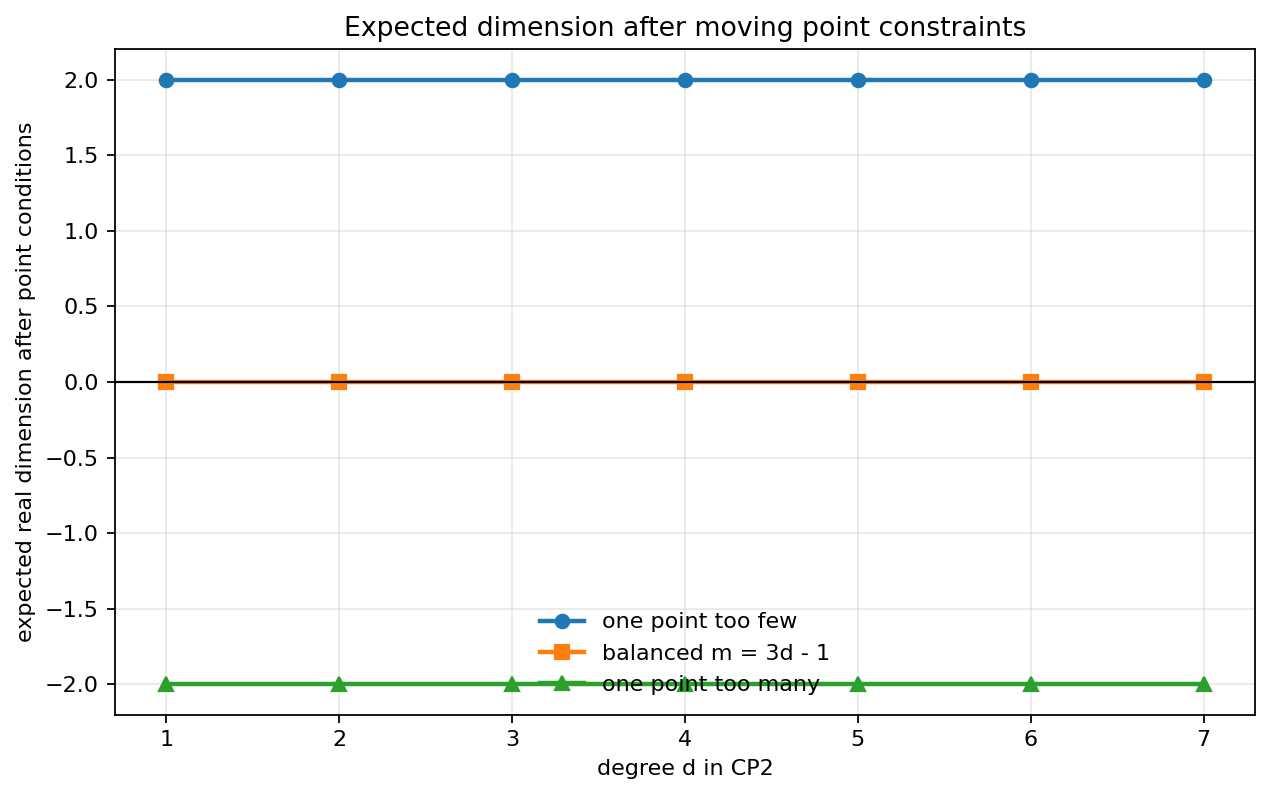

{'passed': True,
 'symbolic_zero_constraint_count': '3*d - 1',
 'formula': 'expected_dim_CP2_genus0 = 6*d - 2 - 2*m',
 'balanced_pairs': [{'degree_d': 1, 'point_constraints_m': 2},
  {'degree_d': 2, 'point_constraints_m': 5},
  {'degree_d': 3, 'point_constraints_m': 8},
  {'degree_d': 4, 'point_constraints_m': 11},
  {'degree_d': 5, 'point_constraints_m': 14},
  {'degree_d': 6, 'point_constraints_m': 17},
  {'degree_d': 7, 'point_constraints_m': 20}],
 'artifact': 'artifacts/chapter-03/figures/expected-dimension-after-point-constraints.png',
 'table': 'artifacts/chapter-03/tables/expected-dimension-constraints.csv'}

In [4]:
d, g, m = sp.symbols("d g m", integer=True, nonnegative=True)
base_genus_zero_cp2 = 6 * d - 2
remaining_genus_zero = base_genus_zero_cp2 - 2 * m
zero_constraint_count = sp.solve(sp.Eq(remaining_genus_zero, 0), m)[0]
assert sp.simplify(zero_constraint_count - (3 * d - 1)) == 0


def teich_dim(genus):
    if genus == 0:
        return 0
    if genus == 1:
        return 2
    return 6 * genus - 6


def aut_dim(genus):
    if genus == 0:
        return 6
    if genus == 1:
        return 2
    return 0


def cp2_param_index(degree, genus):
    return 4 * (1 - genus) + 6 * degree


def cp2_expected_dimension(degree, genus, point_constraints):
    # Stable unparametrized ledger: index + Teichmuller - automorphisms + marks - point constraints.
    return cp2_param_index(degree, genus) + teich_dim(genus) - aut_dim(genus) - 2 * point_constraints


degrees = np.arange(1, 8)
rows = []
for degree in degrees:
    balanced = 3 * degree - 1
    for offset in [-1, 0, 1]:
        points = balanced + offset
        rows.append(
            {
                "degree_d": int(degree),
                "point_constraints_m": int(points),
                "offset_from_3d_minus_1": int(offset),
                "expected_real_dimension": int(cp2_expected_dimension(degree, 0, points)),
            }
        )

dimension_df = pd.DataFrame(rows)
dimension_table_path = TABLE_DIR / "expected-dimension-constraints.csv"
dimension_df.to_csv(dimension_table_path, index=False)

fig, ax = plt.subplots(figsize=(9.2, 5.4))
for offset, label, marker in [(-1, "one point too few", "o"), (0, "balanced m = 3d - 1", "s"), (1, "one point too many", "^")]:
    subset = dimension_df[dimension_df["offset_from_3d_minus_1"] == offset]
    ax.plot(
        subset["degree_d"],
        subset["expected_real_dimension"],
        marker=marker,
        linewidth=2,
        label=label,
    )
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("degree d in CP2")
ax.set_ylabel("expected real dimension after point conditions")
ax.set_title("Expected dimension after moving point constraints")
ax.grid(True, alpha=0.28)
ax.legend(frameon=False)
fig_path = save_matplotlib(fig, UNIT, "figures", "expected-dimension-after-point-constraints.png")
legacy_dimension_fig = save_matplotlib(fig, UNIT, "figures", "transversality-dimension-balance.png")
plt.close(fig)

check = {
    "passed": bool(
        (dimension_df.query("offset_from_3d_minus_1 == 0")["expected_real_dimension"] == 0).all()
        and sp.simplify(zero_constraint_count - (3 * d - 1)) == 0
    ),
    "symbolic_zero_constraint_count": str(zero_constraint_count),
    "formula": "expected_dim_CP2_genus0 = 6*d - 2 - 2*m",
    "balanced_pairs": dimension_df.query("offset_from_3d_minus_1 == 0")[["degree_d", "point_constraints_m"]].to_dict("records"),
    "artifact": rel(fig_path),
    "table": rel(dimension_table_path),
}
expected_dimension_check_path = save_json(check, UNIT, "checks", "expected-dimension-constraints.json")
legacy_dimension_check_path = save_json(check, UNIT, "checks", "transversality-dimension-checks.json")
display_artifact(fig_path, width=760)
display_artifact(dimension_table_path)
check


## 3.2 Universal Moduli And The Cokernel Ledger

The universal moduli space lets `J` vary together with the map. At a pair `(u,J)`, the derivative has two kinds of input: a section along `u` and an infinitesimal change `Y` of the almost complex structure. In schematic form, the new term is `Y(u) du j`. The proof uses simple curves because they have enough injective points: one can localize `Y` near an image point where `du` is nonzero and make it hit a missing cokernel direction.

The finite ledger below deliberately starts with a nonregular fixed-`J` operator: its image misses two target directions. Adding two `J`-variation columns fills exactly those missing directions. This is not a proof of Sard-Smale; it is an inspectable model for the linear algebra that the analytic proof reproduces with Hahn-Banach, elliptic regularity, and injective points.


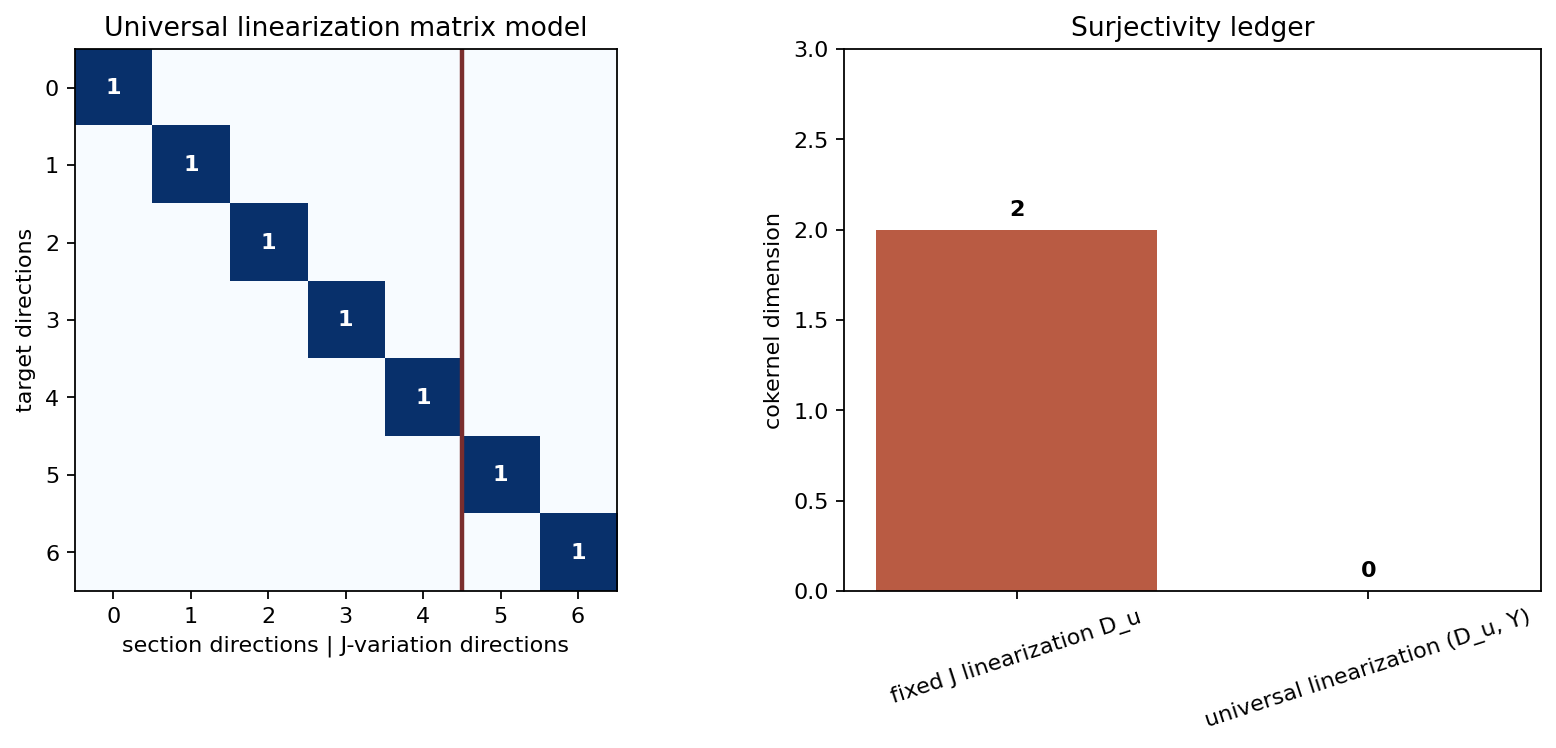

{'passed': True,
 'rank_gain_from_J_variation': 2,
 'fixed_J': {'model': 'fixed J linearization D_u',
  'domain_dimension': 5,
  'target_dimension': 7,
  'rank': 5,
  'kernel_dimension': 0,
  'cokernel_dimension': 2,
  'interpretation': 'not regular: two cokernel directions remain'},
 'universal': {'model': 'universal linearization (D_u, Y)',
  'domain_dimension': 7,
  'target_dimension': 7,
  'rank': 7,
  'kernel_dimension': 0,
  'cokernel_dimension': 0,
  'interpretation': 'regular: J-variation reaches the whole target'},
 'artifact': 'artifacts/chapter-03/figures/rank-cokernel-transversality-ledger.png',
 'table': 'artifacts/chapter-03/tables/rank-cokernel-transversality-ledger.csv'}

In [5]:
D_fixed = np.array(
    [
        [1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
    ],
    dtype=float,
)
J_variation = np.array(
    [
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [1, 0],
        [0, 1],
    ],
    dtype=float,
)
D_universal = np.hstack([D_fixed, J_variation])


def rank_record(name, matrix, interpretation):
    target_dim = matrix.shape[0]
    domain_dim = matrix.shape[1]
    rank = int(np.linalg.matrix_rank(matrix))
    return {
        "model": name,
        "domain_dimension": domain_dim,
        "target_dimension": target_dim,
        "rank": rank,
        "kernel_dimension": domain_dim - rank,
        "cokernel_dimension": target_dim - rank,
        "interpretation": interpretation,
    }


rank_rows = [
    rank_record("fixed J linearization D_u", D_fixed, "not regular: two cokernel directions remain"),
    rank_record("universal linearization (D_u, Y)", D_universal, "regular: J-variation reaches the whole target"),
]
rank_df = pd.DataFrame(rank_rows)
rank_table_path = TABLE_DIR / "rank-cokernel-transversality-ledger.csv"
rank_df.to_csv(rank_table_path, index=False)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.8, 4.8), gridspec_kw={"width_ratios": [1.25, 1]})
ax0.imshow(D_universal, cmap="Blues", vmin=0, vmax=1)
ax0.set_title("Universal linearization matrix model")
ax0.set_xlabel("section directions | J-variation directions")
ax0.set_ylabel("target directions")
ax0.axvline(D_fixed.shape[1] - 0.5, color="#7a2e2e", linewidth=2)
ax0.set_xticks(range(D_universal.shape[1]))
ax0.set_yticks(range(D_universal.shape[0]))
for row in range(D_universal.shape[0]):
    for col in range(D_universal.shape[1]):
        value = D_universal[row, col]
        if value:
            ax0.text(col, row, str(int(value)), ha="center", va="center", color="white", fontsize=10, fontweight="bold")

ax1.bar(rank_df["model"], rank_df["cokernel_dimension"], color=["#b95b43", "#407c59"])
ax1.set_ylabel("cokernel dimension")
ax1.set_title("Surjectivity ledger")
ax1.set_ylim(0, max(rank_df["cokernel_dimension"]) + 1)
ax1.tick_params(axis="x", rotation=18)
for idx, row in rank_df.iterrows():
    ax1.text(idx, row["cokernel_dimension"] + 0.08, str(row["cokernel_dimension"]), ha="center", fontweight="bold")
fig.tight_layout()
rank_fig_path = save_matplotlib(fig, UNIT, "figures", "rank-cokernel-transversality-ledger.png")
plt.close(fig)

rank_check = {
    "passed": bool(rank_rows[0]["cokernel_dimension"] == 2 and rank_rows[1]["cokernel_dimension"] == 0),
    "rank_gain_from_J_variation": int(rank_rows[1]["rank"] - rank_rows[0]["rank"]),
    "fixed_J": rank_rows[0],
    "universal": rank_rows[1],
    "artifact": rel(rank_fig_path),
    "table": rel(rank_table_path),
}
rank_check_path = save_json(rank_check, UNIT, "checks", "rank-cokernel-transversality-ledger.json")
display_artifact(rank_fig_path, width=820)
display_artifact(rank_table_path)
rank_check


## 3.3 Chern-Number Splitting And Automatic Regularity

For spheres, the chapter gives a rare case where regularity can be read from topology. A complex vector bundle over `CP1` splits into line bundles, and a real Cauchy-Riemann operator respecting a filtration is onto exactly when each quotient line has degree at least `-1`. In a four-dimensional target, an immersed sphere has a tangent summand of degree `2`; the normal summand has degree `c1(u^*TM) - 2`. Thus the threshold becomes `c1(u^*TM) >= 1`, equivalently normal degree at least `-1`.

The plot separates tangent and normal degrees for representative cases. The important failure mode is visible at normal degree `-2`: the expected dimension calculation alone does not certify regularity, because the cokernel has appeared in the normal direction.


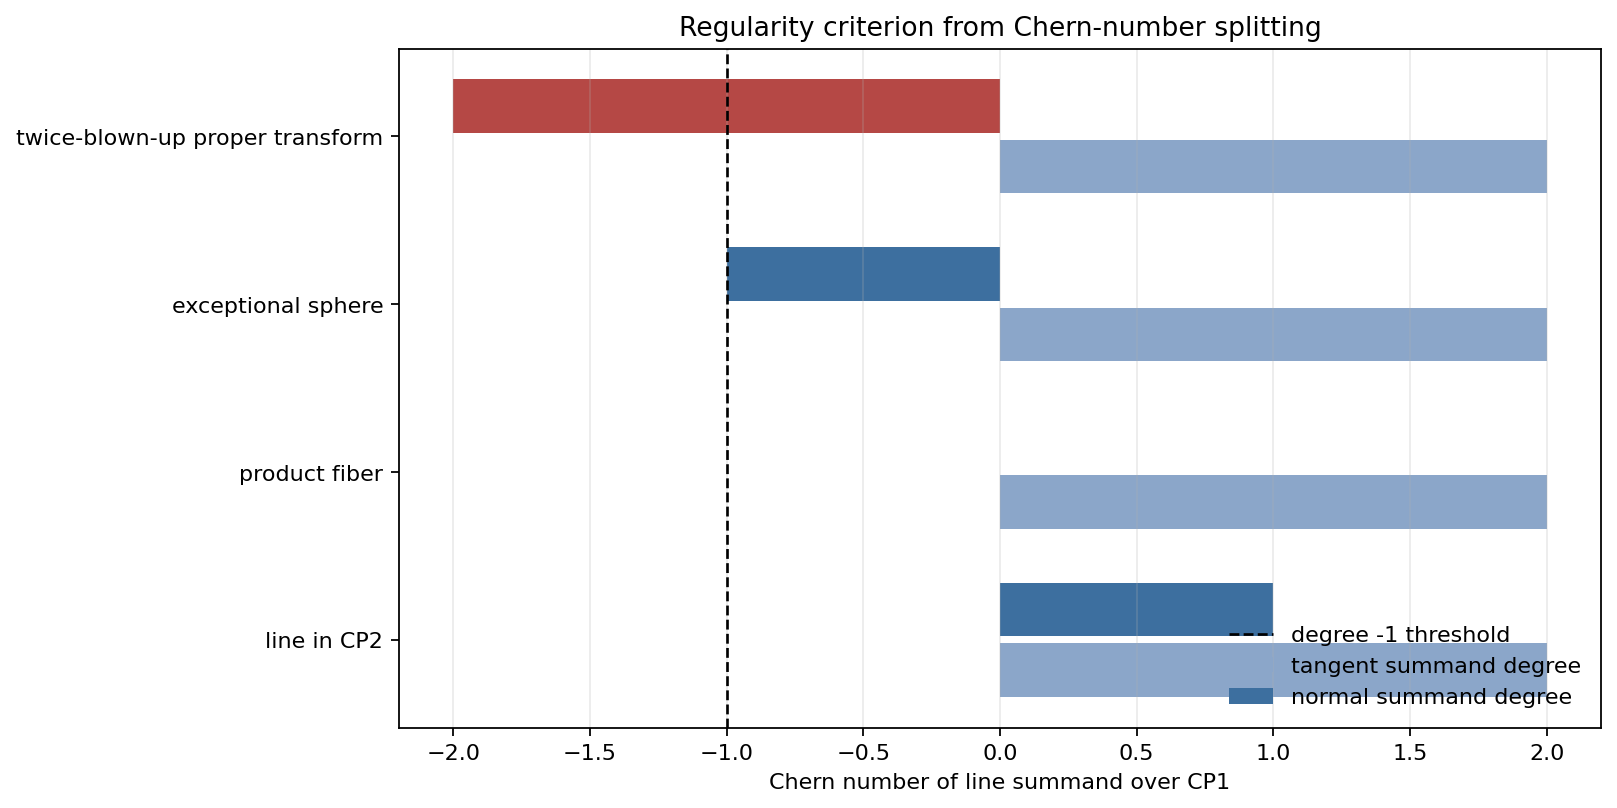

{'passed': True,
 'symbolic_threshold': 'normal_degree >= -1',
 'first_nonregular_normal_degree': -2,
 'rows': [{'case': 'line in CP2',
   'tangent_degree': 2,
   'normal_degree': 1,
   'total_c1': 3,
   'regular_by_splitting_threshold': True},
  {'case': 'product fiber',
   'tangent_degree': 2,
   'normal_degree': 0,
   'total_c1': 2,
   'regular_by_splitting_threshold': True},
  {'case': 'exceptional sphere',
   'tangent_degree': 2,
   'normal_degree': -1,
   'total_c1': 1,
   'regular_by_splitting_threshold': True},
  {'case': 'twice-blown-up proper transform',
   'tangent_degree': 2,
   'normal_degree': -2,
   'total_c1': 0,
   'regular_by_splitting_threshold': False}],
 'artifact': 'artifacts/chapter-03/figures/chern-splitting-regularity-criterion.png',
 'table': 'artifacts/chapter-03/tables/chern-splitting-regularity.csv'}

In [6]:
chern_rows = [
    {"case": "line in CP2", "tangent_degree": 2, "normal_degree": 1},
    {"case": "product fiber", "tangent_degree": 2, "normal_degree": 0},
    {"case": "exceptional sphere", "tangent_degree": 2, "normal_degree": -1},
    {"case": "twice-blown-up proper transform", "tangent_degree": 2, "normal_degree": -2},
]
for row in chern_rows:
    row["total_c1"] = row["tangent_degree"] + row["normal_degree"]
    row["regular_by_splitting_threshold"] = row["tangent_degree"] >= -1 and row["normal_degree"] >= -1

normal_degree = sp.symbols("normal_degree", integer=True)
assert sp.simplify((normal_degree + 1) >= 0) == (normal_degree >= -1)

chern_df = pd.DataFrame(chern_rows)
chern_table_path = TABLE_DIR / "chern-splitting-regularity.csv"
chern_df.to_csv(chern_table_path, index=False)

fig, ax = plt.subplots(figsize=(10.2, 5.2))
y = np.arange(len(chern_df))
colors = ["#3d6f9f" if ok else "#b54845" for ok in chern_df["regular_by_splitting_threshold"]]
ax.barh(y - 0.18, chern_df["tangent_degree"], height=0.32, color="#8ba6c9", label="tangent summand degree")
ax.barh(y + 0.18, chern_df["normal_degree"], height=0.32, color=colors, label="normal summand degree")
ax.axvline(-1, color="black", linewidth=1.2, linestyle="--", label="degree -1 threshold")
ax.set_yticks(y)
ax.set_yticklabels(chern_df["case"])
ax.set_xlabel("Chern number of line summand over CP1")
ax.set_title("Regularity criterion from Chern-number splitting")
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
chern_fig_path = save_matplotlib(fig, UNIT, "figures", "chern-splitting-regularity-criterion.png")
plt.close(fig)

chern_check = {
    "passed": bool((chern_df["regular_by_splitting_threshold"] == (chern_df["normal_degree"] >= -1)).all()),
    "symbolic_threshold": "normal_degree >= -1",
    "first_nonregular_normal_degree": int(chern_df.loc[~chern_df["regular_by_splitting_threshold"], "normal_degree"].max()),
    "rows": chern_df.to_dict("records"),
    "artifact": rel(chern_fig_path),
    "table": rel(chern_table_path),
}
chern_check_path = save_json(chern_check, UNIT, "checks", "chern-splitting-regularity.json")
display_artifact(chern_fig_path, width=800)
display_artifact(chern_table_path)
chern_check


## 3.4 Pointwise Constraints And Evaluation Maps

A point constraint is cleanly expressed by an evaluation map. Fix domain points `w_1,...,w_m`; then `ev_w(u) = (u(w_1),...,u(w_m))`. If the universal evaluation map is transverse to a constraint submanifold `X` in `M^m`, the constrained moduli space has expected dimension

`dim M(A,Sigma;J) - codim(X)`

for fixed domain points. In the enumerative rational-curve ledger above, the preimages of target points are allowed to move, so each marked point also contributes two real domain parameters before the four real target equations are imposed.

The analytic point of Section 3.4 is stronger than the dimension formula. To prove evaluation transversality, the variation of `J` must be localized without damaging already prescribed point values. The same simple-curve injective-point mechanism from universal transversality reappears, now with support control near annuli and with sections required to vanish at chosen points.


## 3.5 Quantitative Implicit Function Theorem

The final section replaces the qualitative statement "a surjective derivative gives a local manifold" with constants. The data are:

- a map `u` whose Cauchy-Riemann defect is small,
- a right inverse `Q_u` for `D_u` with controlled norm,
- a quadratic estimate comparing `F_u(xi+eta)` to its linear approximation.

The theorem then finds an actual zero near the approximate one, and uniqueness holds in the right-inverse slice. In gluing language, the preglued curve is approximate; the right inverse and quadratic estimate give the correction.


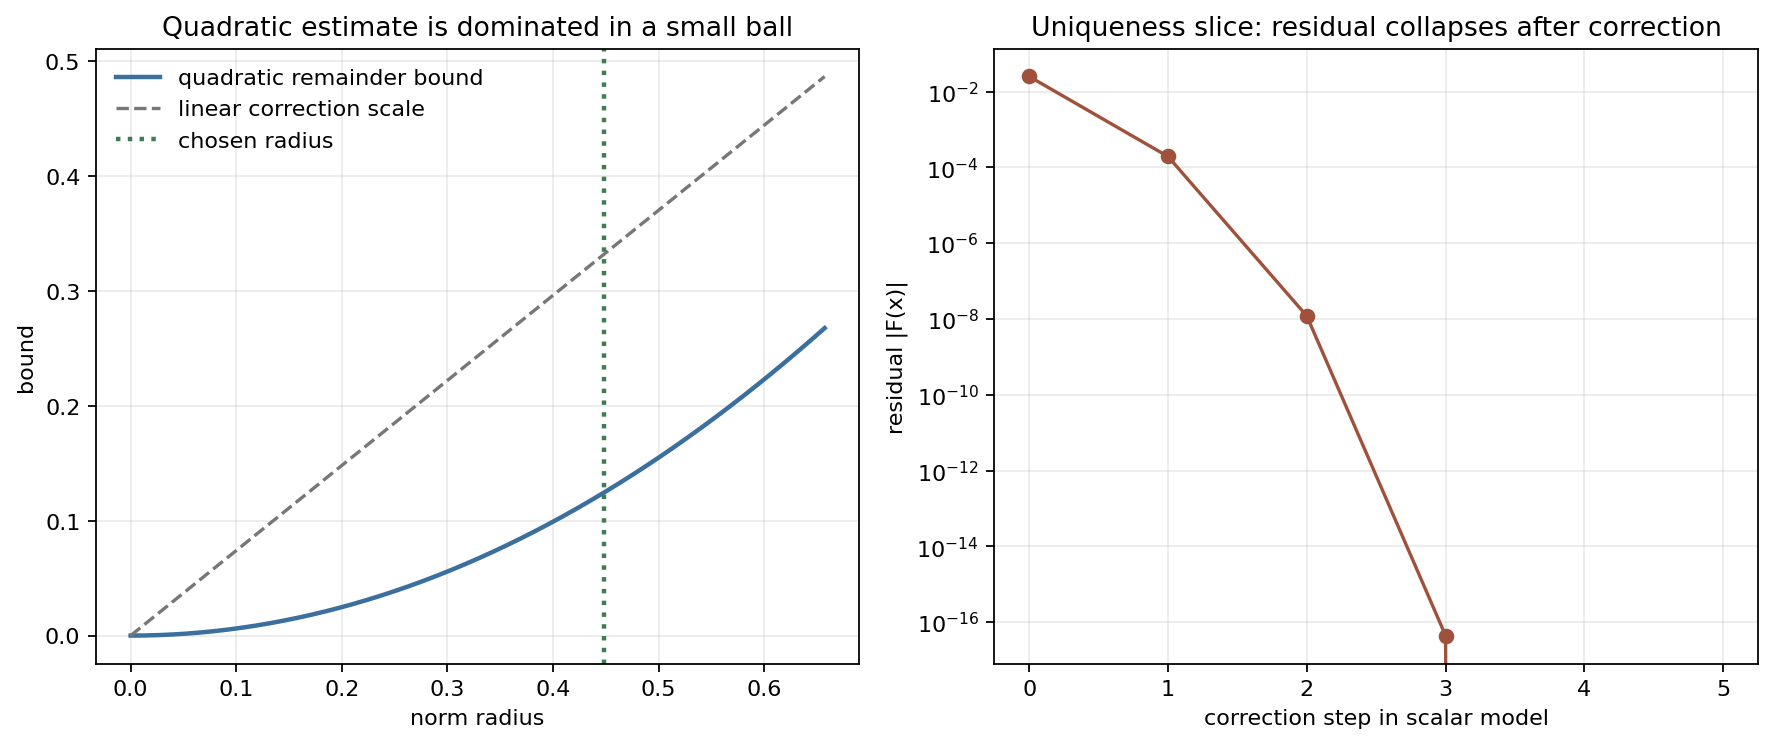

{'passed': True,
 'right_inverse_norm': 1.35,
 'quadratic_constant': 0.62,
 'safe_radius': 0.5973715651135005,
 'chosen_radius': 0.4480286738351254,
 'chosen_contraction_factor': 0.375,
 'initial_residual': 0.025,
 'final_residual': 0.0,
 'artifact': 'artifacts/chapter-03/figures/quadratic-ift-estimate-and-uniqueness.png'}

In [7]:
right_inverse_norm = 1.35
quadratic_constant = 0.62
safe_radius = 1.0 / (2.0 * right_inverse_norm * quadratic_constant)
radii = np.linspace(0.0, min(1.1 * safe_radius, 0.95), 200)
contraction_factor = right_inverse_norm * quadratic_constant * radii
quadratic_remainder_bound = quadratic_constant * radii**2
linear_scale = radii / max(right_inverse_norm, 1e-12)
chosen_radius = 0.75 * safe_radius
chosen_contraction = right_inverse_norm * quadratic_constant * chosen_radius

epsilon = 0.025
a = quadratic_constant / 2.0
x0 = 0.0
newton_iterates = [x0]
for _ in range(5):
    x = newton_iterates[-1]
    F = epsilon + x + a * x * x
    dF = 1 + 2 * a * x
    newton_iterates.append(x - F / dF)
residuals = [abs(epsilon + x + a * x * x) for x in newton_iterates]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.2, 4.8))
ax0.plot(radii, quadratic_remainder_bound, label="quadratic remainder bound", color="#3b6f9e", linewidth=2)
ax0.plot(radii, linear_scale, label="linear correction scale", color="#777777", linestyle="--")
ax0.axvline(chosen_radius, color="#3f7c55", linestyle=":", linewidth=2, label="chosen radius")
ax0.set_xlabel("norm radius")
ax0.set_ylabel("bound")
ax0.set_title("Quadratic estimate is dominated in a small ball")
ax0.grid(True, alpha=0.25)
ax0.legend(frameon=False)

ax1.plot(range(len(residuals)), residuals, marker="o", color="#9f513b")
ax1.set_yscale("log")
ax1.set_xlabel("correction step in scalar model")
ax1.set_ylabel("residual |F(x)|")
ax1.set_title("Uniqueness slice: residual collapses after correction")
ax1.grid(True, which="both", alpha=0.25)
fig.tight_layout()
ift_fig_path = save_matplotlib(fig, UNIT, "figures", "quadratic-ift-estimate-and-uniqueness.png")
plt.close(fig)

ift_check = {
    "passed": bool(chosen_contraction < 0.5 and residuals[-1] < residuals[0] * 1e-8),
    "right_inverse_norm": right_inverse_norm,
    "quadratic_constant": quadratic_constant,
    "safe_radius": safe_radius,
    "chosen_radius": chosen_radius,
    "chosen_contraction_factor": chosen_contraction,
    "initial_residual": residuals[0],
    "final_residual": residuals[-1],
    "artifact": rel(ift_fig_path),
}
ift_check_path = save_json(ift_check, UNIT, "checks", "quadratic-ift-estimate.json")
display_artifact(ift_fig_path, width=840)
ift_check


## Proof Dependency Graph

This graph records the chapter's proof route rather than just its vocabulary. The critical path is:

`universal linearization is onto -> universal moduli is a Banach manifold -> projection to J is Fredholm -> Sard-Smale supplies residual regular values -> regular fibers are finite-dimensional moduli spaces`.

Elliptic regularity enters earlier by making the kernel and cokernel stable analytic objects. Point constraints and the quantitative implicit function theorem are shown as later uses of the same transversality package.


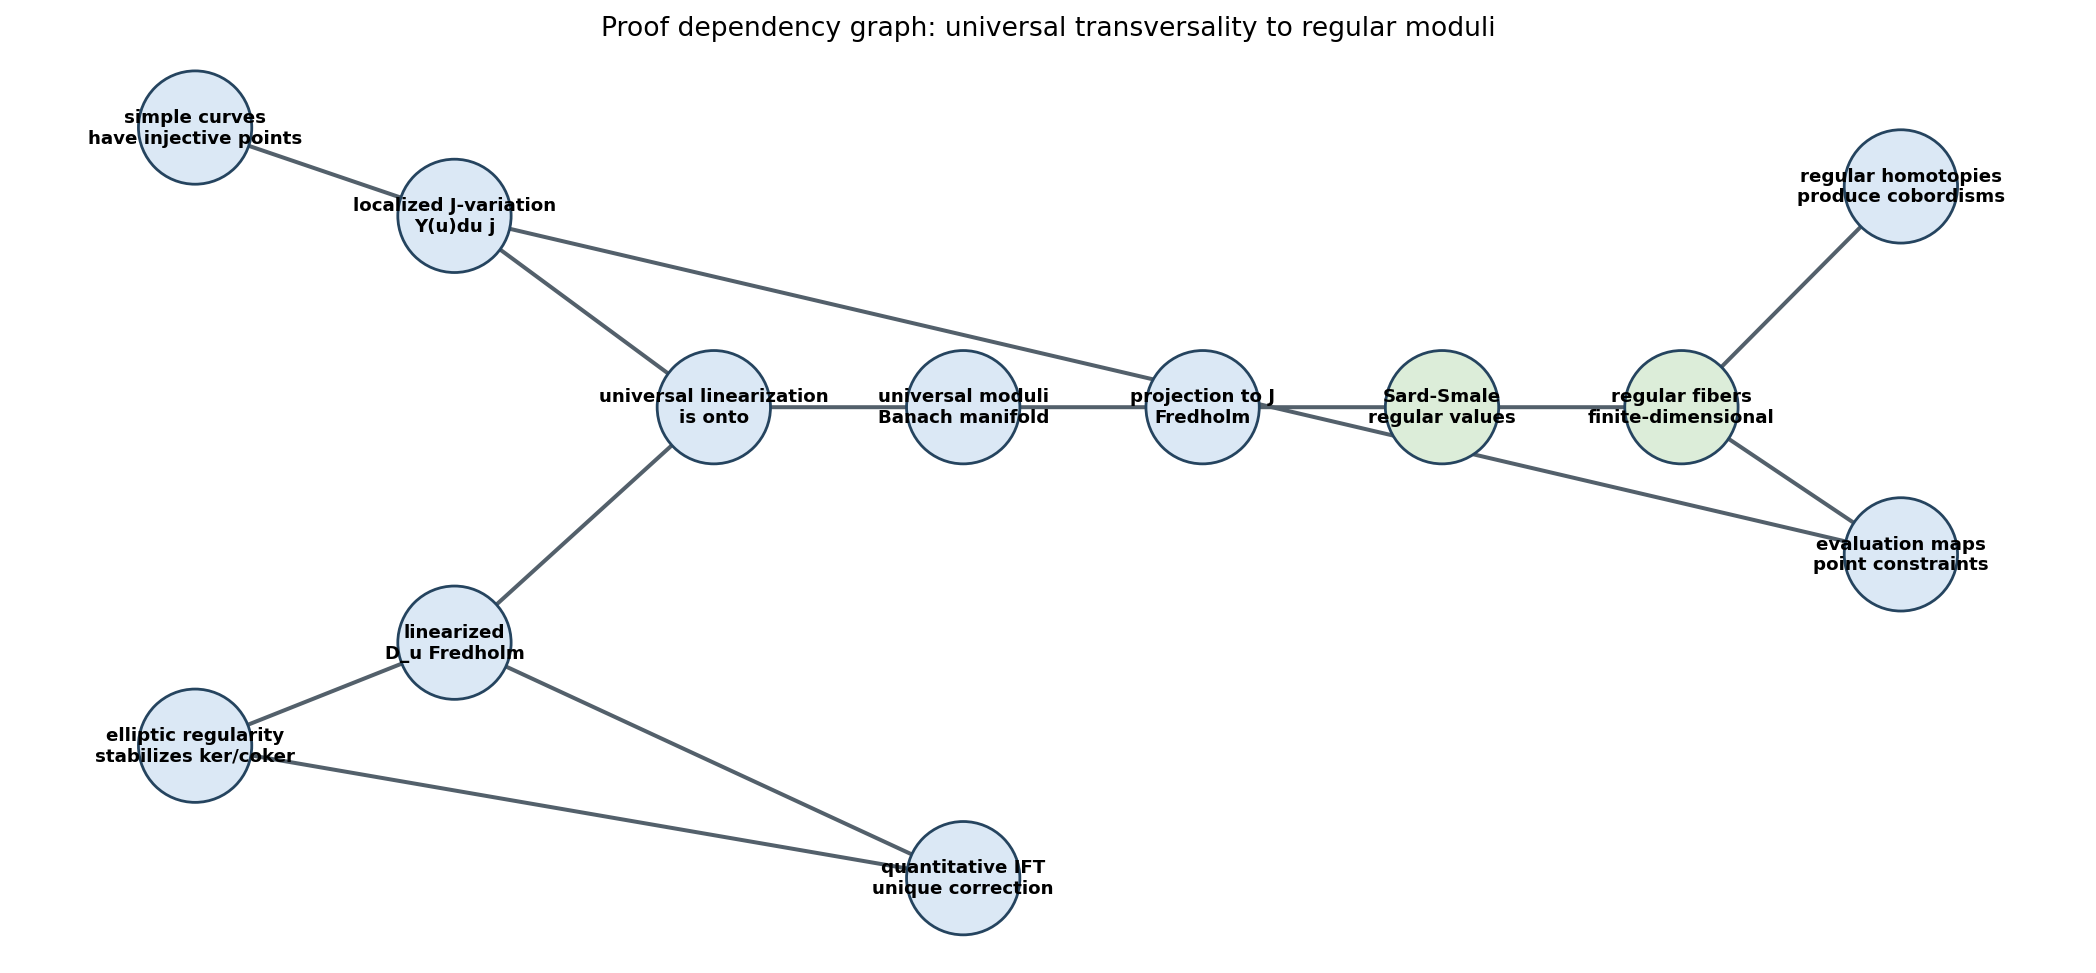

{'passed': True,
 'nodes': 12,
 'edges': 13,
 'is_directed_acyclic_graph': True,
 'required_route': ['universal moduli',
  'projection Fredholm',
  'Sard-Smale',
  'regular moduli'],
 'topological_order_prefix': ['simple curves',
  'elliptic regularity',
  'J variation',
  'linearized operator',
  'universal surjectivity'],
 'artifact': 'artifacts/chapter-03/figures/proof-dependency-map.png'}

In [8]:
proof_nodes = {
    "simple curves": "simple curves\nhave injective points",
    "elliptic regularity": "elliptic regularity\nstabilizes ker/coker",
    "linearized operator": "linearized\nD_u Fredholm",
    "J variation": "localized J-variation\nY(u)du j",
    "universal surjectivity": "universal linearization\nis onto",
    "universal moduli": "universal moduli\nBanach manifold",
    "projection Fredholm": "projection to J\nFredholm",
    "Sard-Smale": "Sard-Smale\nregular values",
    "regular moduli": "regular fibers\nfinite-dimensional",
    "regular homotopy": "regular homotopies\nproduce cobordisms",
    "evaluation maps": "evaluation maps\npoint constraints",
    "quantitative IFT": "quantitative IFT\nunique correction",
}
proof_edges = [
    ("simple curves", "J variation"),
    ("elliptic regularity", "linearized operator"),
    ("linearized operator", "universal surjectivity"),
    ("J variation", "universal surjectivity"),
    ("universal surjectivity", "universal moduli"),
    ("universal moduli", "projection Fredholm"),
    ("projection Fredholm", "Sard-Smale"),
    ("Sard-Smale", "regular moduli"),
    ("regular moduli", "regular homotopy"),
    ("J variation", "evaluation maps"),
    ("regular moduli", "evaluation maps"),
    ("linearized operator", "quantitative IFT"),
    ("elliptic regularity", "quantitative IFT"),
]
G = nx.DiGraph()
G.add_nodes_from(proof_nodes)
G.add_edges_from(proof_edges)
route = ["universal moduli", "projection Fredholm", "Sard-Smale", "regular moduli"]
assert all(G.has_edge(a, b) for a, b in zip(route, route[1:]))

pos = {
    "simple curves": (-2.5, 1.3),
    "elliptic regularity": (-2.5, -0.8),
    "linearized operator": (-1.2, -0.45),
    "J variation": (-1.2, 1.0),
    "universal surjectivity": (0.1, 0.35),
    "universal moduli": (1.35, 0.35),
    "projection Fredholm": (2.55, 0.35),
    "Sard-Smale": (3.75, 0.35),
    "regular moduli": (4.95, 0.35),
    "regular homotopy": (6.05, 1.1),
    "evaluation maps": (6.05, -0.15),
    "quantitative IFT": (1.35, -1.25),
}
fig, ax = plt.subplots(figsize=(13.2, 6.2))
node_colors = ["#dbe8f5" if node not in {"Sard-Smale", "regular moduli"} else "#dcedd9" for node in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.8, edge_color="#53606b")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2600, node_color=node_colors, edgecolors="#25445f", linewidths=1.25)
nx.draw_networkx_labels(G, pos, labels=proof_nodes, font_size=8.2, font_weight="bold")
ax.set_title("Proof dependency graph: universal transversality to regular moduli")
ax.set_axis_off()
fig.tight_layout()
proof_fig_path = save_matplotlib(fig, UNIT, "figures", "proof-dependency-map.png")
plt.close(fig)

proof_check = {
    "passed": bool(nx.is_directed_acyclic_graph(G) and all(G.has_edge(a, b) for a, b in zip(route, route[1:]))),
    "nodes": len(G.nodes),
    "edges": len(G.edges),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G),
    "required_route": route,
    "topological_order_prefix": list(nx.topological_sort(G))[:5],
    "artifact": rel(proof_fig_path),
}
proof_check_path = save_json(proof_check, UNIT, "checks", "proof-dependency-map.json")
display_artifact(proof_fig_path, width=940)
proof_check


## Applied Lab

Use the saved HTML lab to vary degree, genus, and number of point constraints in a `CP2` index ledger. This is an index experiment, not an existence theorem: negative expected dimension warns that a generic constraint set should be empty, while positive expected dimension warns that a count is not yet zero-dimensional.

The lab uses the stable unparametrized bookkeeping

`expected_dim = ind(D_u) + dim Teich(Sigma) - dim Aut(Sigma) - 2m`

for point conditions in a four-dimensional target, where `ind(D_u)=4(1-g)+6d` for the `CP2` class of degree `d`. For genus zero this reduces to `6d - 2 - 2m`, so the zero-dimensional ridge occurs at `m=3d-1`.


In [9]:
lab_degrees = np.arange(1, 9)
lab_constraints = np.arange(0, 31)
lab_genera = [0, 1, 2, 3]

heatmaps = {}
zero_pairs = []
for genus in lab_genera:
    z = np.array([[cp2_expected_dimension(degree, genus, constraints) for constraints in lab_constraints] for degree in lab_degrees])
    heatmaps[genus] = z
    for i, degree in enumerate(lab_degrees):
        for j, constraints in enumerate(lab_constraints):
            if z[i, j] == 0:
                zero_pairs.append({"genus": genus, "degree_d": int(degree), "point_constraints_m": int(constraints)})

fig = go.Figure()
for idx, genus in enumerate(lab_genera):
    fig.add_trace(
        go.Heatmap(
            z=heatmaps[genus],
            x=lab_constraints,
            y=lab_degrees,
            colorscale="RdBu",
            zmid=0,
            colorbar=dict(title="real dim"),
            visible=(idx == 0),
            hovertemplate="genus=%{customdata}<br>d=%{y}<br>m=%{x}<br>expected dim=%{z}<extra></extra>",
            customdata=np.full_like(heatmaps[genus], genus),
        )
    )
buttons = []
for idx, genus in enumerate(lab_genera):
    visible = [False] * len(lab_genera)
    visible[idx] = True
    buttons.append(
        dict(
            label=f"genus {genus}",
            method="update",
            args=[{"visible": visible}, {"title": f"Expected dimension lab: genus {genus}"}],
        )
    )
fig.update_layout(
    title="Expected dimension lab: genus 0",
    xaxis_title="point constraints m",
    yaxis_title="degree d",
    width=900,
    height=560,
    updatemenus=[dict(type="buttons", direction="right", x=0.02, y=1.12, buttons=buttons)],
)
lab_html_path = HTML_DIR / "degree-genus-constraint-lab.html"
fig.write_html(lab_html_path, include_plotlyjs="inline", full_html=True)

lab_check = {
    "passed": bool(all({"genus": 0, "degree_d": int(degree), "point_constraints_m": int(3 * degree - 1)} in zero_pairs for degree in lab_degrees)),
    "formula": "4*(1-g)+6*d + teich_dim(g) - aut_dim(g) - 2*m",
    "degrees": lab_degrees.tolist(),
    "genera": lab_genera,
    "constraint_range": [int(lab_constraints.min()), int(lab_constraints.max())],
    "zero_dimensional_pairs_sample": zero_pairs[:18],
    "artifact": rel(lab_html_path),
}
lab_check_path = save_json(lab_check, UNIT, "checks", "applied-lab-dimension-grid.json")
display_artifact(lab_html_path, width="100%", height=600)
lab_check


{'passed': True,
 'formula': '4*(1-g)+6*d + teich_dim(g) - aut_dim(g) - 2*m',
 'degrees': [1, 2, 3, 4, 5, 6, 7, 8],
 'genera': [0, 1, 2, 3],
 'constraint_range': [0, 30],
 'zero_dimensional_pairs_sample': [{'genus': 0,
   'degree_d': 1,
   'point_constraints_m': 2},
  {'genus': 0, 'degree_d': 2, 'point_constraints_m': 5},
  {'genus': 0, 'degree_d': 3, 'point_constraints_m': 8},
  {'genus': 0, 'degree_d': 4, 'point_constraints_m': 11},
  {'genus': 0, 'degree_d': 5, 'point_constraints_m': 14},
  {'genus': 0, 'degree_d': 6, 'point_constraints_m': 17},
  {'genus': 0, 'degree_d': 7, 'point_constraints_m': 20},
  {'genus': 0, 'degree_d': 8, 'point_constraints_m': 23},
  {'genus': 1, 'degree_d': 1, 'point_constraints_m': 3},
  {'genus': 1, 'degree_d': 2, 'point_constraints_m': 6},
  {'genus': 1, 'degree_d': 3, 'point_constraints_m': 9},
  {'genus': 1, 'degree_d': 4, 'point_constraints_m': 12},
  {'genus': 1, 'degree_d': 5, 'point_constraints_m': 15},
  {'genus': 1, 'degree_d': 6, 'point_const

## Takeaways

- Regularity is a surjectivity statement about the linearized Cauchy-Riemann operator, not a vague smoothness condition.
- Elliptic regularity keeps kernel and cokernel data independent of the Sobolev completion used to build the Banach manifold.
- Universal transversality works because simple curves have injective points where changes in `J` can be localized to hit missing cokernel directions.
- For spheres, Chern-number splitting gives concrete automatic regularity thresholds; in dimension four, normal degree `-2` is the visible obstruction case in this notebook.
- Point constraints should be read through evaluation maps and codimension bookkeeping.
- The quantitative implicit function theorem is the analytic engine behind later gluing: approximate solutions become genuine ones when the right inverse and quadratic estimate are uniformly controlled.

## Final Sanity Checks

The final cell asserts the required artifacts, checks the JSON pass flags, verifies symbolic identities, and writes `final-sanity.json` under `artifacts/chapter-03/checks/`.


In [10]:
assert_artifact(FIG_DIR / "expected-dimension-after-point-constraints.png")
assert_artifact(FIG_DIR / "rank-cokernel-transversality-ledger.png")
assert_artifact(FIG_DIR / "proof-dependency-map.png")
assert_artifact(FIG_DIR / "chern-splitting-regularity-criterion.png")
assert_artifact(FIG_DIR / "quadratic-ift-estimate-and-uniqueness.png")
assert_artifact(HTML_DIR / "degree-genus-constraint-lab.html", min_bytes=1024)
assert_artifact(TABLE_DIR / "expected-dimension-constraints.csv", min_bytes=80)
assert_artifact(TABLE_DIR / "rank-cokernel-transversality-ledger.csv", min_bytes=80)
assert_artifact(CHECK_DIR / "source-coverage.json", min_bytes=80)
assert_artifact(CHECK_DIR / "library-routing.json", min_bytes=80)
assert_artifact(CHECK_DIR / "visual-storyboard.json", min_bytes=80)

check_files = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "expected-dimension-constraints.json",
    CHECK_DIR / "rank-cokernel-transversality-ledger.json",
    CHECK_DIR / "chern-splitting-regularity.json",
    CHECK_DIR / "proof-dependency-map.json",
    CHECK_DIR / "quadratic-ift-estimate.json",
    CHECK_DIR / "applied-lab-dimension-grid.json",
]
loaded_checks = {}
for path in check_files:
    data = json.loads(path.read_text(encoding="utf-8"))
    assert data.get("passed") is True, path
    loaded_checks[path.name] = data

assert sp.simplify((6 * d - 2 - 2 * (3 * d - 1))) == 0
assert rank_check["universal"]["cokernel_dimension"] == 0
assert chern_check["rows"][-1]["regular_by_splitting_threshold"] == False
assert ift_check["chosen_contraction_factor"] < 0.5

final_sanity = {
    "passed": True,
    "notebook": "chapter-03-moduli-spaces-and-transversality/03-moduli-spaces-and-transversality.ipynb",
    "source_span": "printed pp. 39-74; PDF pp. 54-89",
    "artifact_count_checked": 11,
    "json_checks_checked": sorted(loaded_checks),
    "symbolic_dimension_identity": "6*d - 2 - 2*(3*d - 1) == 0",
    "universal_cokernel_dimension": rank_check["universal"]["cokernel_dimension"],
    "nonregular_normal_degree_case": chern_check["rows"][-1],
    "quadratic_ift_contraction_factor": ift_check["chosen_contraction_factor"],
}
final_sanity_path = save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(final_sanity_path, min_bytes=80)
final_sanity


{'passed': True,
 'notebook': 'chapter-03-moduli-spaces-and-transversality/03-moduli-spaces-and-transversality.ipynb',
 'source_span': 'printed pp. 39-74; PDF pp. 54-89',
 'artifact_count_checked': 11,
 'json_checks_checked': ['applied-lab-dimension-grid.json',
  'chern-splitting-regularity.json',
  'expected-dimension-constraints.json',
  'library-routing.json',
  'proof-dependency-map.json',
  'quadratic-ift-estimate.json',
  'rank-cokernel-transversality-ledger.json',
  'source-coverage.json',
  'visual-storyboard.json'],
 'symbolic_dimension_identity': '6*d - 2 - 2*(3*d - 1) == 0',
 'universal_cokernel_dimension': 0,
 'nonregular_normal_degree_case': {'case': 'twice-blown-up proper transform',
  'tangent_degree': 2,
  'normal_degree': -2,
  'total_c1': 0,
  'regular_by_splitting_threshold': False},
 'quadratic_ift_contraction_factor': 0.375}